<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>

<h1 align=center><font size = 5>Assignment: SQL Notebook for Peer Assignment</font></h1>

Estimated time needed: **60** minutes.

En esta tarea, vamos a predecir si la primera etapa del Falcon 9 aterrizará con éxito. SpaceX anuncia los lanzamientos del cohete Falcon 9 en su sitio web con un costo de 62 millones de dólares; otros proveedores cuestan más de 165 millones de dólares cada uno, gran parte del ahorro se debe a que SpaceX puede reutilizar la primera etapa.

En este laboratorio, realizarás Análisis Exploratorio de Datos y Creación de Características.

## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Exploratory Data Analysis

In [6]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(URL)
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Primero, intentemos ver cómo las variables `FlightNumber` (que indica los intentos continuos de lanzamiento) y `Payload` afectarían el resultado del lanzamiento.

Podemos graficar <code>FlightNumber</code> vs. <code>PayloadMass</code> y superponer el resultado del lanzamiento. Vemos que a medida que aumenta el número de vuelo, es más probable que la primera etapa aterrice con éxito. La masa de la carga útil también parece ser un factor; incluso con cargas útiles más pesadas, la primera etapa a menudo regresa con éxito.

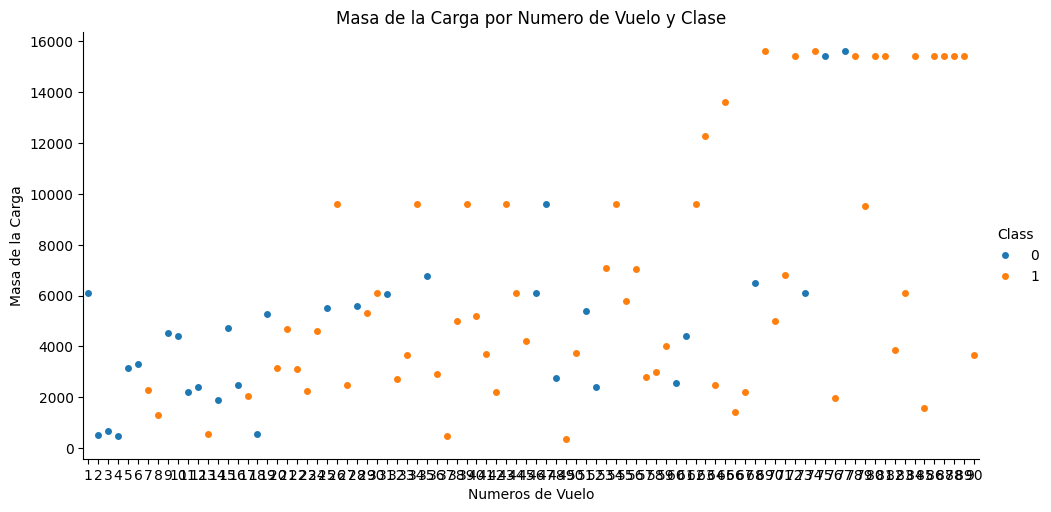

In [11]:
sns.catplot(x="FlightNumber", y="PayloadMass", hue="Class", data=df, aspect=2)
plt.xlabel("Numeros de Vuelo")
plt.ylabel("Masa de la Carga")
plt.title("Masa de la Carga por Numero de Vuelo y Clase")
plt.show()

### TASK 1: Visualize the relationship between Flight Number and Launch Site
Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>

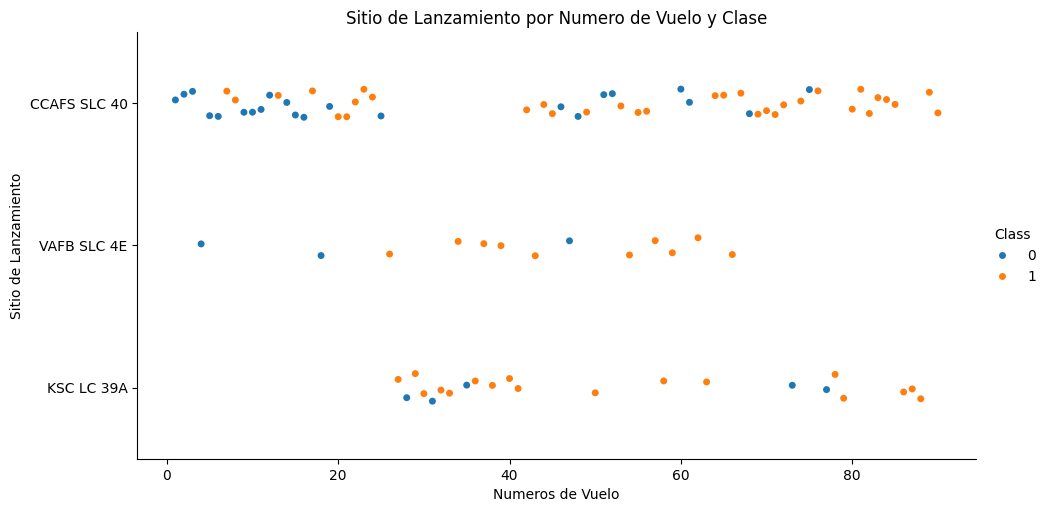

In [12]:
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=2)
plt.xlabel("Numeros de Vuelo")
plt.ylabel("Sitio de Lanzamiento")
plt.title("Sitio de Lanzamiento por Numero de Vuelo y Clase")
plt.show()

In [ ]:
# Ahora intenta explicar los patrones que encontraste en los gráficos de dispersión de Número de Vuelo vs. Sitio de Lanzamiento.

A ver lo que indica es que en los primeros sitios de lanzamiento el que comenzó primero tuvieron Fracasos En los 20 primeros Números de vuelo En la primera plataforma Mientras más Intentos vuelos De 20 para arriba Comenzaron a tener éxitos Y eso se ve en las siguientes plataformas también Pero las siguientes comenzaron mucho más tarde Eso significa de que aprendieron del primer error del primer sitio de lanzamiento Y comenzaron a tener éxito Eso indica que hay una correlación Entre más cantidad de vuelos e intentos Con el éxito Aprendido de los fracasos anteriores

### TASK 2: Visualize the relationship between Payload Mass and Launch Site
We also want to observe if there is any relationship between launch sites and their payload mass.

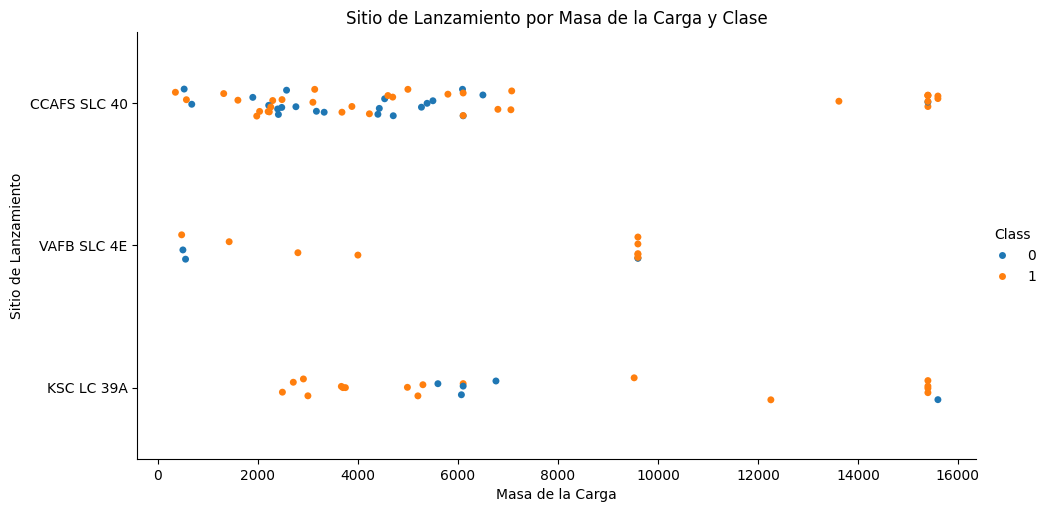

In [13]:
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=2)
plt.xlabel("Masa de la Carga")
plt.ylabel("Sitio de Lanzamiento")
plt.title("Sitio de Lanzamiento por Masa de la Carga y Clase")
plt.show()

Ahora, si observas el diagrama de dispersión de Masa de Carga Útil vs. Sitio de Lanzamiento, verás que para el sitio de lanzamiento VAFB-SLC no se han lanzado cohetes con carga pesada (mayor a 10000).
### TASK  3: Visualize the relationship between success rate of each orbit type
A continuación, queremos revisar visualmente si hay alguna relación entre la tasa de éxito y el tipo de órbita.

In [ ]:
# HINT use groupby method on Orbit column and get the mean of Class column
df.groupby("Orbit")["Class"].mean()

Orbit
ES-L1    1.000000
GEO      1.000000
GTO      0.518519
HEO      1.000000
ISS      0.619048
LEO      0.714286
MEO      0.666667
PO       0.666667
SO       0.000000
SSO      1.000000
VLEO     0.857143
Name: Class, dtype: float64

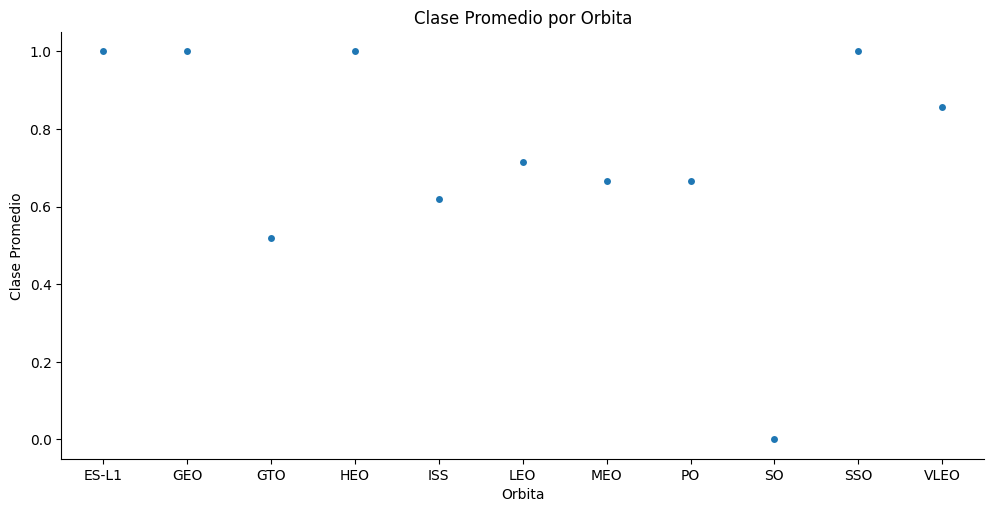

In [15]:
sns.catplot(x="Orbit", y="Class", data=df.groupby("Orbit")["Class"].mean().reset_index(), aspect=2)
plt.xlabel("Orbita")
plt.ylabel("Clase Promedio")
plt.title("Clase Promedio por Orbita")
plt.show()

### TASK  4: Visualize the relationship between FlightNumber and Orbit type

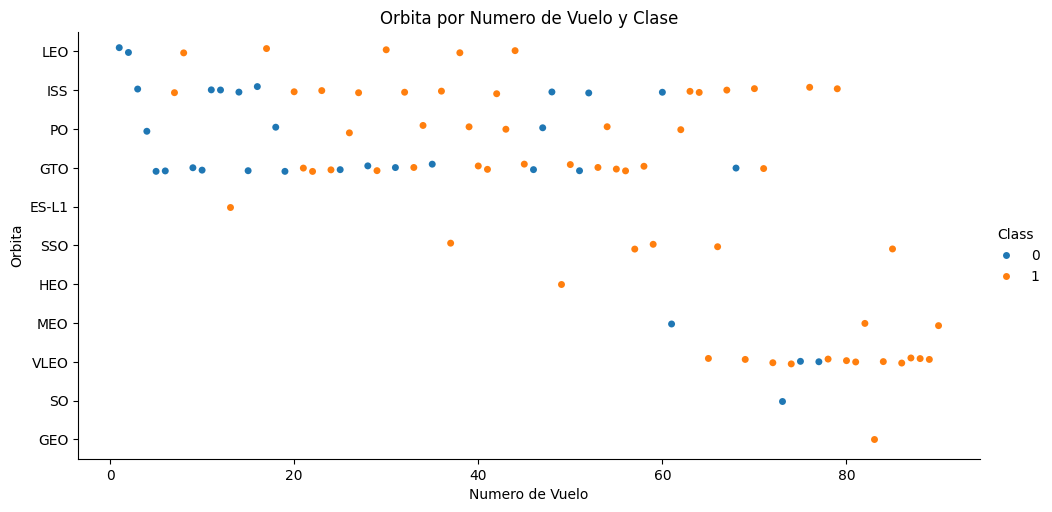

In [16]:
sns.catplot(x="FlightNumber", y="Orbit", data=df, hue="Class", aspect=2)
plt.xlabel("Numero de Vuelo")
plt.ylabel("Orbita")
plt.title("Orbita por Numero de Vuelo y Clase")
plt.show()

Puedes observar que en la órbita LEO, el éxito parece estar relacionado con el número de vuelos. En cambio, en la órbita GTO, parece que no hay relación entre el número de vuelos y el éxito.
### TASK  5: Visualize the relationship between Payload Mass and Orbit type

Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type

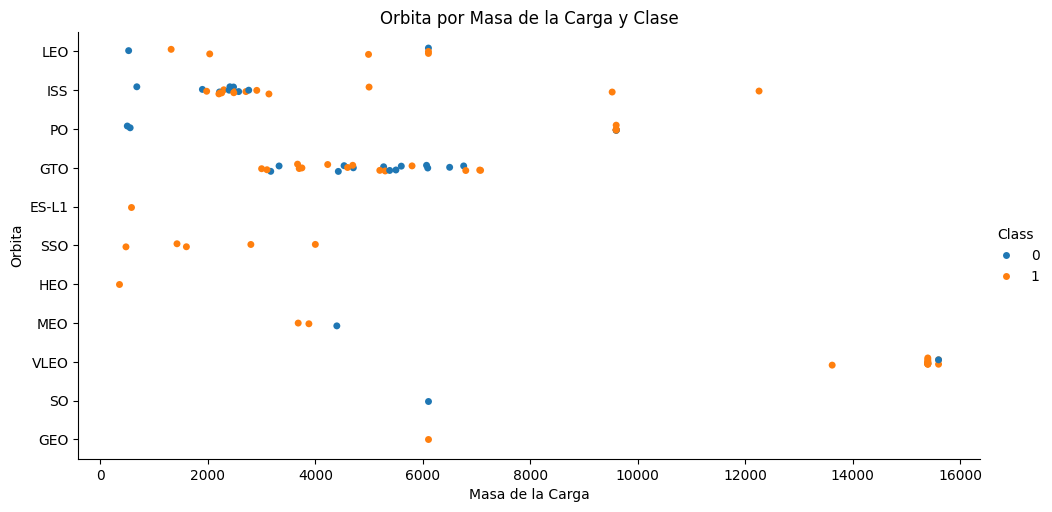

In [17]:
sns.catplot(x="PayloadMass", y="Orbit", data=df, hue="Class", aspect=2)
plt.xlabel("Masa de la Carga")
plt.ylabel("Orbita")
plt.title("Orbita por Masa de la Carga y Clase")
plt.show()

Con cargas pesadas, el aterrizaje exitoso o la tasa de aterrizajes positivos son mayores para Polar, LEO y ISS.

Sin embargo, para GTO, es difícil distinguir entre aterrizajes exitosos y no exitosos, ya que ambos resultados están presentes.
### TASK  6: Visualize the launch success yearly trend

Puedes hacer un gráfico de líneas con el eje x como <code>Year</code> y el eje y como la tasa de éxito promedio, para ver la tendencia promedio de éxito en los lanzamientos

In [18]:
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


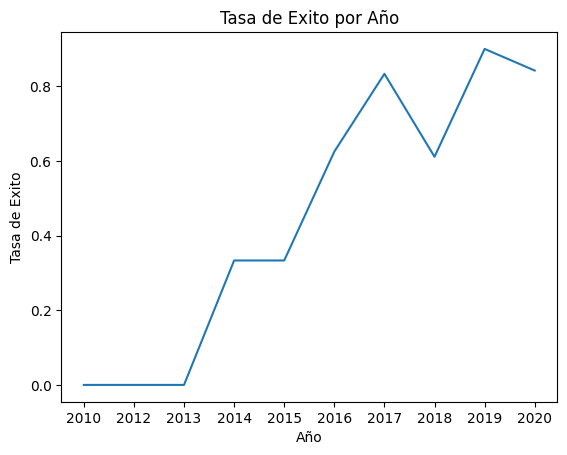

In [19]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
sns.lineplot(x="Date", y="Class", data=df.groupby("Date")["Class"].mean().reset_index())
plt.xlabel("Año")
plt.ylabel("Tasa de Exito")
plt.title("Tasa de Exito por Año")
plt.show()

puedes observar que la tasa de éxito desde 2013 siguió aumentando hasta 2020
## Features Engineering

Para ahora, ya deberías tener algunas ideas preliminares sobre cómo cada variable importante podría afectar la tasa de éxito; seleccionaremos las características que se usarán en la predicción de éxito en el módulo futuro.

In [20]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### TASK  7: Create dummy variables to categorical columns
Usa la función <code>get_dummies</code> y el dataframe <code>features</code> para aplicar OneHotEncoder a las columnas <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code> y <code>Serial</code>. Asigna el valor a la variable <code>features_one_hot</code> y muestra los resultados usando el método head. Tu dataframe resultante debe incluir todas las características, incluyendo las codificadas.

In [21]:
# HINT: Use get_dummies() function on the categorical columns
features = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`

Ahora que nuestro dataframe features_one_hot solo contiene números, convierte todo el dataframe al tipo de variable float64

In [22]:
features = features.astype('float64')
features.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Ahora podemos exportarlo a un <b>CSV</b> para la siguiente sección, pero para mantener las respuestas consistentes, en el próximo laboratorio proporcionaremos los datos en un rango de fechas preseleccionado.

In [23]:
features.to_csv("dataset_part_3.csv", index=False)